In [1]:
# Import statements
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import itertools
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt



In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
final_df = pd.read_csv('final_merged_output.csv')


In [4]:
final_df = final_df[(final_df['Year'] < 2023)]

In [5]:
features = ['Median Household Income', 'Total Population', 'INDPRO', 'VIXCLS', 'CPI', 'Unemployment Rate', 'City GDP']
scaler = StandardScaler()

final_df[features] = final_df.groupby('City')[features].transform(lambda x: (x - x.mean()) / x.std())


In [ ]:
results = {}

for city, city_df in final_df.groupby('City'):

    ols_train_size = int(len(city_df) * 0.9)
    ols_train_df = city_df.iloc[:ols_train_size]

    X = ols_train_df[features]
    y = ols_train_df['index_nsa']
    X = sm.add_constant(X)  

    model = sm.OLS(y, X).fit()
    results[city] = model
    print(f"{city} — R²: {model.rsquared:.3f}, Adj. R²: {model.rsquared_adj:.3f}")
    print(model.summary())

Chicago — R²: 0.891, Adj. R²: 0.884
                            OLS Regression Results                            
Dep. Variable:              index_nsa   R-squared:                       0.891
Model:                            OLS   Adj. R-squared:                  0.884
Method:                 Least Squares   F-statistic:                     128.4
Date:                Mon, 01 Dec 2025   Prob (F-statistic):           6.49e-50
Time:                        04:01:27   Log-Likelihood:                -460.10
No. Observations:                 118   AIC:                             936.2
Df Residuals:                     110   BIC:                             958.4
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

In [7]:
# final_df['ols_predicted_hpi'] = final_df.groupby('City').apply(
#     lambda g: results[g.name].predict(sm.add_constant(g[features]))
# ).reset_index(level=0, drop=True)

# final_df['residual'] = final_df['index_nsa'] - final_df['ols_predicted_hpi']


final_df['ols_predicted_hpi'] = np.nan


for city, city_df in final_df.groupby('City'):
    model = results[city]

    X_full = sm.add_constant(city_df[features], has_constant='skip')

    preds = model.predict(X_full)

    final_df.loc[city_df.index, 'ols_predicted_hpi'] = preds

final_df['residual'] = final_df['index_nsa'] - final_df['ols_predicted_hpi']


In [8]:
final_df['ols_predicted_hpi']

0       92.459691
1       94.562953
2       94.165291
3       94.447204
4       88.823352
          ...    
695    252.141528
696    279.635324
697    262.206777
698    245.407849
699    240.821440
Name: ols_predicted_hpi, Length: 660, dtype: float64

In [9]:



p = d = q = range(0, 3)
pdq = list(itertools.product(p, d, q))

best_orders = {}
arima_results = {}

for city, city_df in final_df.groupby('City'):
    city_df = city_df.sort_values(['Year', 'Quarter'])
    noise_train_size = int(len(city_df) * 0.9)
    noise_train_df = city_df.iloc[:noise_train_size]
    residuals = noise_train_df['residual'].dropna()

    best_aic = np.inf
    best_order = None
    best_model = None

    for order in pdq:
        try:
            model = ARIMA(residuals, order=order)
            fitted = model.fit()
            if fitted.aic < best_aic:
                best_aic = fitted.aic
                best_order = order
                best_model = fitted
        except Exception:
            continue

    best_orders[city] = best_order
    arima_results[city] = best_model
    print(f"{city}: best order = {best_order}, AIC = {best_aic:.2f}")


Chicago: best order = (2, 1, 2), AIC = 686.95
Houston: best order = (2, 1, 2), AIC = 493.15
Los Angeles: best order = (2, 1, 2), AIC = 945.46
New York: best order = (2, 1, 2), AIC = 896.76
Phoenix: best order = (2, 1, 2), AIC = 887.05


In [10]:
# for city, city_df in final_df.groupby('City'):
#     regression_pred = results[city].predict(sm.add_constant(city_df[features]))
#     arima_pred = arima_results[city].predict()
    
#     final_df.loc[city_df.index, 'noise_hpi_forecast'] = regression_pred + arima_pred

final_df['noise_hpi_forecast'] = np.nan  

for city, city_df in final_df.groupby('City'):
    city_df = city_df.sort_values(['Year', 'Quarter']).copy()

    
    ols_model = results[city]
    arima_model = arima_results[city]

    regression_pred = ols_model.predict(sm.add_constant(city_df[features]))

    n_total = len(city_df)
    n_train = int(n_total * 0.9)

    fitted_part = arima_model.fittedvalues
    forecast_part = arima_model.get_forecast(steps=n_total - n_train).predicted_mean

    arima_pred = np.concatenate([fitted_part, forecast_part])

    if len(arima_pred) < n_total:
        arima_pred = np.pad(arima_pred, (n_total - len(arima_pred), 0), constant_values=np.nan)
    elif len(arima_pred) > n_total:
        arima_pred = arima_pred[:n_total]

    hybrid_forecast = city_df['ols_predicted_hpi'] + arima_pred

    final_df.loc[city_df.index, 'noise_hpi_forecast'] = hybrid_forecast


In [11]:
final_df.isna().sum()


City                       0
Year                       0
Quarter                    0
index_nsa                  0
Median Household Income    0
Total Population           0
INDPRO                     0
VIXCLS                     0
CPI                        0
Unemployment Rate          0
City GDP                   0
ols_predicted_hpi          0
residual                   0
noise_hpi_forecast         0
dtype: int64

In [12]:

#HPI arima
p = d = q = range(0, 3)
pdq = list(itertools.product(p, d, q))

best_orders_raw = {}
arima_results_raw = {}

for city, city_df in final_df.groupby('City'):
    city_df = city_df.sort_values(['Year', 'Quarter'])
    arima_train_size = int(len(city_df) * 0.9)
    arima_train_df = city_df.iloc[:arima_train_size]
    series = arima_train_df['index_nsa'].dropna()

    best_aic = np.inf
    best_order = None
    best_model = None

    for order in pdq:
        try:
            model = ARIMA(series, order=order)
            fitted = model.fit()
            if fitted.aic < best_aic:
                best_aic = fitted.aic
                best_order = order
                best_model = fitted
        except Exception:
            continue

    best_orders_raw[city] = best_order
    arima_results_raw[city] = best_model
    print(f"{city}: best ARIMA order = {best_order}, AIC = {best_aic:.2f}")



final_df['arima_predicted_hpi'] = np.nan  

for city, city_df in final_df.groupby('City'):
    city_df = city_df.sort_values(['Year', 'Quarter']).copy()

    arima_model = arima_results_raw[city]

    
    n_total = len(city_df)
    n_train = int(n_total * 0.9)

    fitted_part = arima_model.fittedvalues
    forecast_part = arima_model.get_forecast(steps=n_total - n_train).predicted_mean

    arima_pred = np.concatenate([fitted_part, forecast_part])

    if len(arima_pred) < n_total:
        arima_pred = np.pad(arima_pred, (n_total - len(arima_pred), 0), constant_values=np.nan)
    elif len(arima_pred) > n_total:
        arima_pred = arima_pred[:n_total]

    final_df.loc[city_df.index, 'arima_predicted_hpi'] = arima_pred




Chicago: best ARIMA order = (2, 2, 0), AIC = 403.65
Houston: best ARIMA order = (2, 2, 2), AIC = 397.26
Los Angeles: best ARIMA order = (2, 2, 1), AIC = 602.37
New York: best ARIMA order = (2, 2, 0), AIC = 478.69
Phoenix: best ARIMA order = (2, 2, 2), AIC = 619.38


In [13]:
final_df.isna().sum()

City                       0
Year                       0
Quarter                    0
index_nsa                  0
Median Household Income    0
Total Population           0
INDPRO                     0
VIXCLS                     0
CPI                        0
Unemployment Rate          0
City GDP                   0
ols_predicted_hpi          0
residual                   0
noise_hpi_forecast         0
arima_predicted_hpi        0
dtype: int64

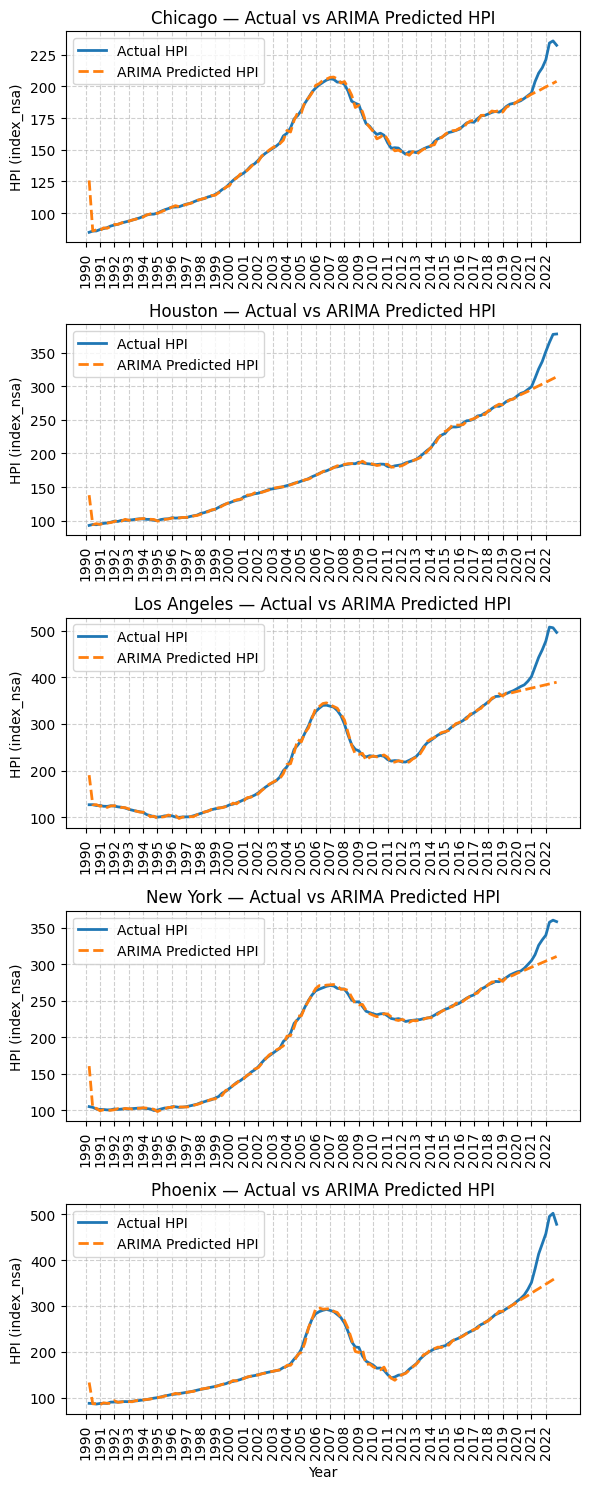

In [31]:
final_df = final_df.sort_values(['City', 'Year', 'Quarter'])
cities = final_df['City'].unique()

fig, axes = plt.subplots(len(cities), 1, figsize=(6, 3 * len(cities)), sharex=False)

for ax, city in zip(axes, cities):
    city_df = final_df[final_df['City'] == city].copy()
    city_df = city_df.iloc[1:]

    city_df['TimeIndex'] = (city_df['Year'] - city_df['Year'].min()) * 4 + (city_df['Quarter'] - 1)

    ax.plot(
        city_df['TimeIndex'], city_df['index_nsa'],
        label='Actual HPI', linewidth=2
    )
    ax.plot(
        city_df['TimeIndex'], city_df['arima_predicted_hpi'],
        label='ARIMA Predicted HPI', linestyle='--', linewidth=2
    )

    ax.set_title(f"{city} — Actual vs ARIMA Predicted HPI")
    ax.set_ylabel("HPI (index_nsa)")
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()

    unique_years = sorted(city_df['Year'].unique())
    ticks = [(y - city_df['Year'].min()) * 4 for y in unique_years]
    ax.set_xticks(ticks)
    ax.set_xticklabels(unique_years)
    ax.set_xticklabels(unique_years, rotation=90)

axes[-1].set_xlabel("Year")
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()



In [15]:
final_df

,City,Year,Quarter,index_nsa,Median Household Income,Total Population,INDPRO,VIXCLS,CPI,Unemployment Rate,City GDP,ols_predicted_hpi,residual,noise_hpi_forecast,arima_predicted_hpi
0,Chicago,1990,1,83.83,-1.503776,0.068244,-2.078336,0.355232,1.836914,0.057305,-1.594201,92.459691,-8.629691,92.459691,0.000000
1,Chicago,1990,2,84.81,-1.503776,0.068244,-2.044978,-0.129633,1.836914,-0.039673,-1.578560,94.562953,-9.752953,85.933233,125.745043
2,Chicago,1990,3,85.80,-1.503776,0.068244,-2.025572,0.774136,1.836914,-0.007347,-1.568693,94.165291,-8.365291,84.236670,85.790044
3,Chicago,1990,4,85.87,-1.503776,0.068244,-2.099142,0.897215,1.836914,-0.168976,-1.570553,94.447204,-8.577204,86.625910,86.788389
4,Chicago,1991,1,86.95,-1.477975,0.076091,-2.187673,0.391798,1.060072,0.332075,-1.564688,88.823352,-1.873352,79.770730,86.201299
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,Phoenix,2021,4,435.76,2.378480,1.610676,0.882646,-0.047258,1.369273,-1.067649,1.500861,252.141528,183.618472,278.126446,342.610137
696,Phoenix,2022,1,457.57,2.560574,1.674091,0.956767,0.804556,3.576871,-1.013563,1.788070,279.635324,177.934676,304.720817,347.716501
697,Phoenix,2022,2,495.27,2.742668,1.737505,1.031928,1.083103,3.576871,-0.923420,1.788070,262.206777,233.063223,288.150394,352.514574
698,Phoenix,2022,3,502.20,2.924762,1.800919,1.058939,0.725872,3.576871,-0.761163,1.788070,245.407849,256.792151,270.532753,357.296258


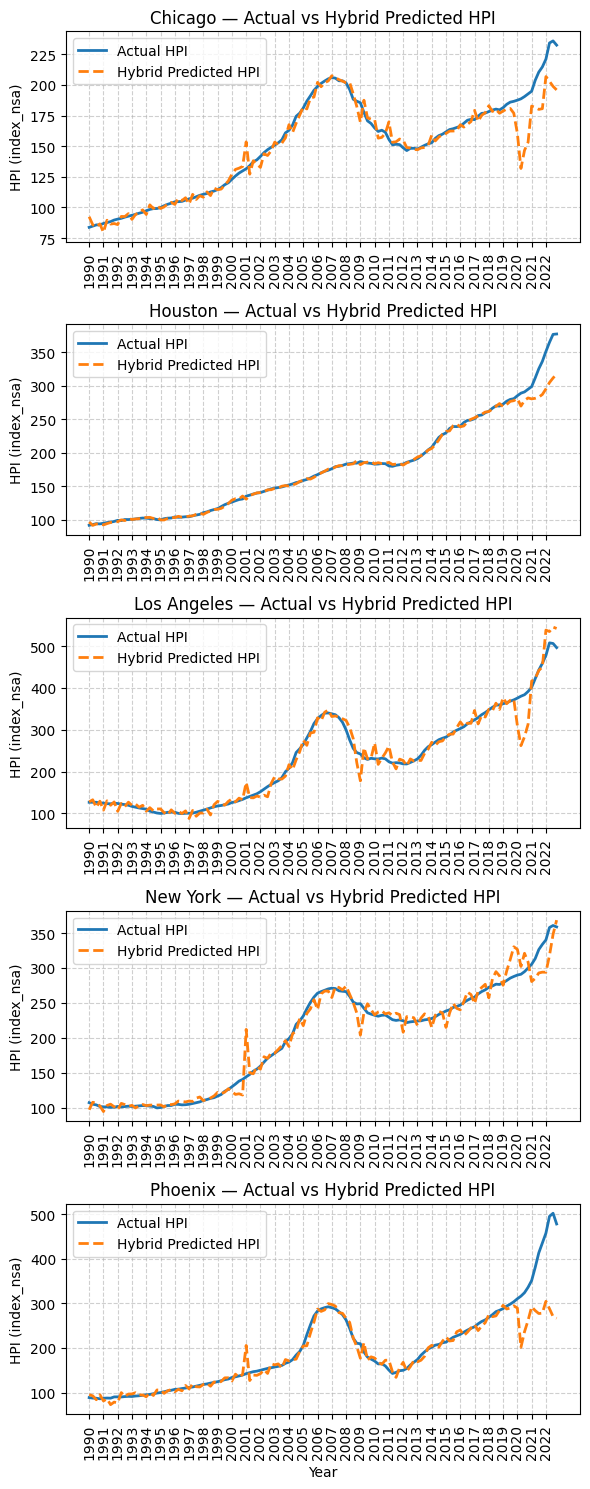

In [30]:

final_df = final_df.sort_values(['City', 'Year', 'Quarter'])
cities = final_df['City'].unique()

fig, axes = plt.subplots(len(cities), 1, figsize=(6, 3 * len(cities)), sharex=False)

for ax, city in zip(axes, cities):
    city_df = final_df[final_df['City'] == city].copy()

    city_df['TimeIndex'] = (city_df['Year'] - city_df['Year'].min()) * 4 + (city_df['Quarter'] - 1)

    ax.plot(
        city_df['TimeIndex'], city_df['index_nsa'],
        label='Actual HPI', linewidth=2
    )
    ax.plot(
        city_df['TimeIndex'], city_df['noise_hpi_forecast'],
        label='Hybrid Predicted HPI', linestyle='--', linewidth=2
    )

    ax.set_title(f"{city} — Actual vs Hybrid Predicted HPI")
    ax.set_ylabel("HPI (index_nsa)")
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()

    unique_years = sorted(city_df['Year'].unique())
    ticks = [(y - city_df['Year'].min()) * 4 for y in unique_years]
    ax.set_xticks(ticks)
    ax.set_xticklabels(unique_years)
    ax.set_xticklabels(unique_years, rotation=90)

axes[-1].set_xlabel("Year")
plt.xticks(rotation = 90)

plt.tight_layout()
plt.show()


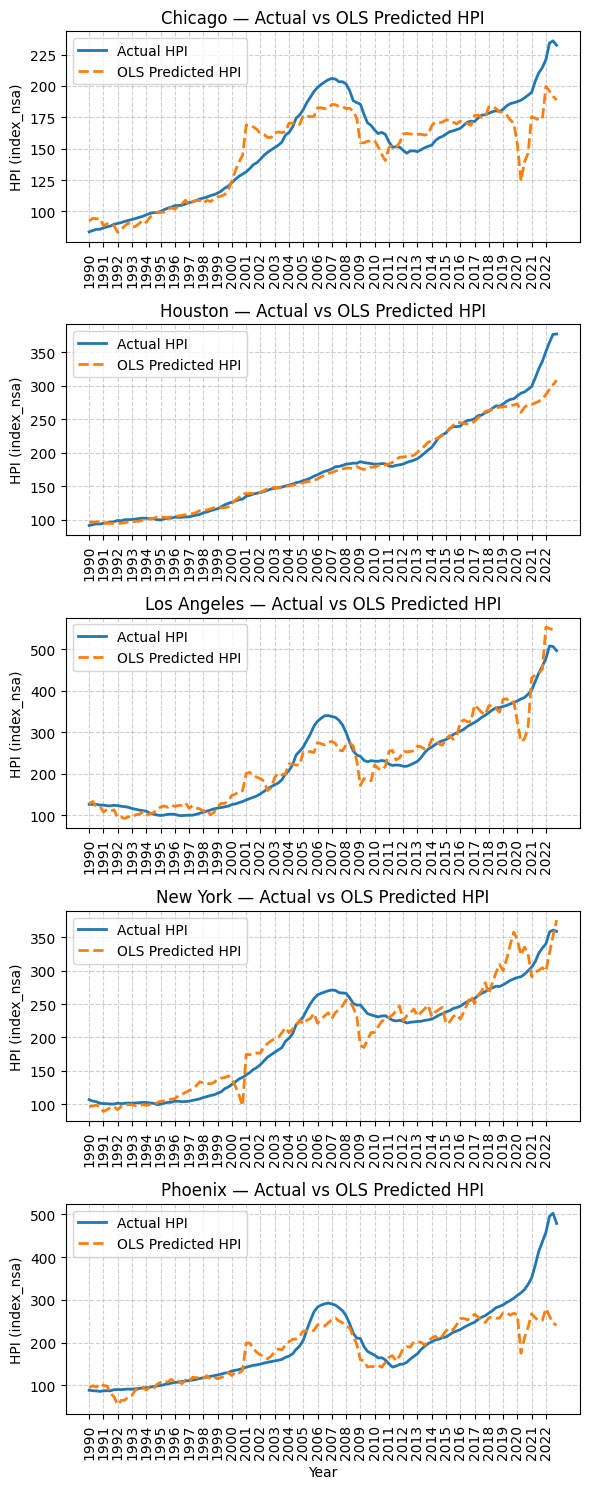

In [32]:

final_df = final_df.sort_values(['City', 'Year', 'Quarter'])
cities = final_df['City'].unique()

fig, axes = plt.subplots(len(cities), 1, figsize=(6, 3 * len(cities)), sharex=False)

for ax, city in zip(axes, cities):
    city_df = final_df[final_df['City'] == city].copy()

    city_df['TimeIndex'] = (city_df['Year'] - city_df['Year'].min()) * 4 + (city_df['Quarter'] - 1)

    ax.plot(
        city_df['TimeIndex'], city_df['index_nsa'],
        label='Actual HPI', linewidth=2
    )
    ax.plot(
        city_df['TimeIndex'], city_df['ols_predicted_hpi'],
        label='OLS Predicted HPI', linestyle='--', linewidth=2
    )

    ax.set_title(f"{city} — Actual vs OLS Predicted HPI")
    ax.set_ylabel("HPI (index_nsa)")
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()

    unique_years = sorted(city_df['Year'].unique())
    ticks = [(y - city_df['Year'].min()) * 4 for y in unique_years]
    ax.set_xticks(ticks)
    ax.set_xticklabels(unique_years)
    ax.set_xticklabels(unique_years, rotation=90)

axes[-1].set_xlabel("Year")
plt.xticks(rotation = 90)

plt.tight_layout()
plt.show()

In [33]:
#training on 90%

features = [
    'Median Household Income', 'Total Population', 'INDPRO',
    'VIXCLS', 'CPI', 'Unemployment Rate', 'City GDP'
]

results_summary = []

for city, city_df in final_df.groupby('City'):
    city_df = city_df.sort_values(['Year', 'Quarter']).reset_index(drop=True)
    
  
    train_size = int(len(city_df) * 0.9)
    train_df = city_df.iloc[:train_size]
    test_df = city_df.iloc[train_size:]


    hpi_train_size = int(len(city_df.iloc[1:]) * 0.9)
    hpi_train_df = city_df.iloc[1:hpi_train_size]
    hpi_test_df = city_df.iloc[hpi_train_size:]


    # ols
    ols_pred_test = test_df['ols_predicted_hpi']
    ols_mae = mean_absolute_error(test_df['index_nsa'], ols_pred_test)
    ols_rmse = np.sqrt(mean_squared_error(test_df['index_nsa'], ols_pred_test))
    

    # hpi \arima
    arima_pred_test = hpi_test_df['arima_predicted_hpi']
    arima_mae = mean_absolute_error(hpi_test_df['index_nsa'], arima_pred_test)
    arima_rmse = np.sqrt(mean_squared_error(hpi_test_df['index_nsa'], arima_pred_test))
   

    hybrid_pred_test = test_df['noise_hpi_forecast']
    hybrid_mae = mean_absolute_error(test_df['index_nsa'], hybrid_pred_test)
    hybrid_rmse = np.sqrt(mean_squared_error(test_df['index_nsa'], hybrid_pred_test))


    results_summary.append({
        'City': city,
        'OLS_MAE': round(ols_mae, 2),
        'OLS_RMSE': round(ols_rmse, 2),
        'Noise_MAE': round(hybrid_mae, 2),
        'Noise_RMSE': round(hybrid_rmse, 2),
        'ARIMA_MAE': round(arima_mae, 2),
        'ARIMA_RMSE': round(arima_rmse, 2),
        'ARIMA Order Used - Noise': best_orders.get(city),
        'ARIMA Order Used - HPI': best_orders_raw.get(city),
    })

results_df = pd.DataFrame(results_summary)
print(results_df)


# for city, city_df in final_df.groupby('City'):
#     city_df = city_df.sort_values(['Year', 'Quarter']).reset_index(drop=True)
#     hpi_city_df = city_df.iloc[1:]

#     train_size = int(len(city_df) * 0.9)
#     train_df = city_df.iloc[:train_size]
#     test_df = city_df.iloc[train_size:]

#     hpi_train_size = int(len(hpi_city_df) * 0.9)
#     hpi_train_df = hpi_city_df.iloc[:hpi_train_size]
#     hpi_test_df = hpi_city_df.iloc[hpi_train_size:]

#     # ols
#     X_train = sm.add_constant(train_df[features])
#     y_train = train_df['index_nsa']
#     X_test = sm.add_constant(test_df[features])

#     ols_model = sm.OLS(y_train, X_train).fit()
#     ols_pred_train = ols_model.predict(X_train)
#     ols_pred_test = ols_model.predict(X_test)

#     ols_mae = mean_absolute_error(test_df['index_nsa'], ols_pred_test)
#     ols_rmse = np.sqrt(mean_squared_error(test_df['index_nsa'], ols_pred_test))

#     # noise arima
#     residuals_train = y_train - ols_pred_train
#     order = best_orders.get(city, (1, 1, 1))  

#     try:
#         arima_model = ARIMA(residuals_train, order=order)
#         arima_fit = arima_model.fit()
#         arima_forecast = arima_fit.forecast(steps=len(test_df))

#         hybrid_forecast = ols_pred_test + arima_forecast.values
#         hybrid_mae = mean_absolute_error(test_df['index_nsa'], hybrid_forecast)
#         hybrid_rmse = np.sqrt(mean_squared_error(test_df['index_nsa'], hybrid_forecast))
#     except Exception as e:
#         hybrid_mae, hybrid_rmse = np.nan, np.nan

#     # HPI arima
#     try:
#         arima_model_hpi = ARIMA(hpi_train_df['index_nsa'], order=best_orders_raw.get(city))
#         arima_fit_hpi = arima_model_hpi.fit()
#         arima_forecast_only = arima_fit_hpi.forecast(steps=len(hpi_test_df))

#         arima_mae = mean_absolute_error(hpi_test_df['index_nsa'], arima_forecast_only)
#         arima_rmse = np.sqrt(mean_squared_error(hpi_test_df['index_nsa'], arima_forecast_only))
#     except Exception as e:
#         arima_mae, arima_rmse = np.nan, np.nan

#     results_summary.append({
#         'City': city,
#         'OLS_MAE': round(ols_mae, 2),
#         'OLS_RMSE': round(ols_rmse, 2),
#         'Hybrid_MAE': round(hybrid_mae, 2),
#         'Hybrid_RMSE': round(hybrid_rmse, 2),
#         'ARIMA_MAE': round(arima_mae, 2),
#         'ARIMA_RMSE': round(arima_rmse, 2),
#         'ARIMA Order Used - Noise': order,
#         'ARIMA Order Used - HPI': best_orders_raw.get(city),
#     })

# results_df = pd.DataFrame(results_summary)
# print(results_df)

          City  OLS_MAE  OLS_RMSE  Noise_MAE  Noise_RMSE  ARIMA_MAE  \
0      Chicago    35.67     38.32      28.57       31.82      10.73   
1      Houston    39.46     45.73      31.21       38.55      21.17   
2  Los Angeles    42.35     54.49      40.27       55.35      46.57   
3     New York    32.91     37.08      27.66       30.35      18.93   
4      Phoenix   137.52    155.18     111.98      133.04      51.98   

   ARIMA_RMSE ARIMA Order Used - Noise ARIMA Order Used - HPI  
0       16.39                (2, 1, 2)              (2, 2, 0)  
1       32.34                (2, 1, 2)              (2, 2, 2)  
2       64.28                (2, 1, 2)              (2, 2, 1)  
3       26.93                (2, 1, 2)              (2, 2, 0)  
4       74.97                (2, 1, 2)              (2, 2, 2)  


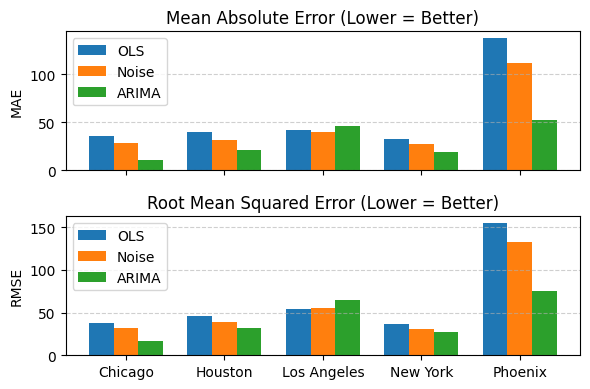

In [34]:


for col in ['OLS_MAE', 'OLS_RMSE', 'Noise_MAE', 'Noise_RMSE', 'ARIMA_MAE', 'ARIMA_RMSE']:
    results_df[col] = results_df[col].astype(float)

cities = results_df['City']
x = np.arange(len(cities))
width = 0.25

fig, ax = plt.subplots(2, 1, figsize=(6, 4), sharex=True)


ax[0].bar(x - width, results_df['OLS_MAE'], width, label='OLS')
ax[0].bar(x, results_df['Noise_MAE'], width, label='Noise')
ax[0].bar(x + width, results_df['ARIMA_MAE'], width, label='ARIMA')
ax[0].set_ylabel('MAE')
ax[0].set_title('Mean Absolute Error (Lower = Better)')
ax[0].legend()
ax[0].grid(axis='y', linestyle='--', alpha=0.6)

ax[1].bar(x - width, results_df['OLS_RMSE'], width, label='OLS')
ax[1].bar(x, results_df['Noise_RMSE'], width, label='Noise')
ax[1].bar(x + width, results_df['ARIMA_RMSE'], width, label='ARIMA')
ax[1].set_ylabel('RMSE')
ax[1].set_title('Root Mean Squared Error (Lower = Better)')
ax[1].set_xticks(x)
ax[1].set_xticklabels(cities)
ax[1].legend()
ax[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [20]:


# tscv = TimeSeriesSplit(n_splits=5)
# cv_results = []
# #cross validation - time series splits for rolling windows, repeating averahe performance
# for city, city_df in final_df.groupby("City"):
#     city_df = city_df.sort_values(["Year","Quarter"]).reset_index(drop=True)
#     X = city_df[features]
#     y = city_df["index_nsa"]

#     fold_id = 1
#     for train_idx, test_idx in tscv.split(X):
#         X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
#         y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

#         #OLS

#         X_train_c, X_test_c = sm.add_constant(X_train, has_constant="add"), sm.add_constant(X_test, has_constant="add")
#         ols_model = sm.OLS(y_train, X_train_c).fit()
#         ols_pred = ols_model.predict(X_test_c)

#         ols_mae = mean_absolute_error(y_test, ols_pred)
#         ols_rmse = np.sqrt(mean_squared_error(y_test, ols_pred))
#         ols_mape = mean_absolute_percentage_error(y_test, ols_pred) * 100

#         #noise arima
#         train_resid = y_train - ols_model.predict(X_train_c)

#         best_aic, best_order, best_model = np.inf, None, None
#         best_order = best_orders.get(city)
#         best_model = ARIMA(train_resid, order=best_order).fit()

#         hybrid_resid_forecast = best_model.forecast(steps=len(y_test))
#         hybrid_forecast = ols_pred + hybrid_resid_forecast

#         hybrid_mae = mean_absolute_error(y_test, hybrid_forecast)
#         hybrid_rmse = np.sqrt(mean_squared_error(y_test, hybrid_forecast))
#         hybrid_mape = mean_absolute_percentage_error(y_test, hybrid_forecast) * 100
        
        
#         # hpi arima
#         best_aic, best_order_raw, best_model_raw = np.inf, None, None
#         best_model_raw = ARIMA(y_train, order=best_orders_raw.get(city)).fit()

#         arima_forecast = best_model_raw.forecast(steps=len(y_test))
#         arima_mae = mean_absolute_error(y_test, arima_forecast)
#         arima_rmse = np.sqrt(mean_squared_error(y_test, arima_forecast))
#         arima_mape = mean_absolute_percentage_error(y_test, arima_forecast) * 100
        
#         cv_results.append({
#             "City": city,
#             "Fold": fold_id,
#             "OLS_MAE": ols_mae,
#             "OLS_RMSE": ols_rmse,
#             "OLS_MAPE": ols_mape,
#             "Hybrid_MAE": hybrid_mae,
#             "Hybrid_RMSE": hybrid_rmse,
#             "Hybrid_MAPE": hybrid_mape,
#             "ARIMA_MAE": arima_mae,
#             "ARIMA_RMSE": arima_rmse,
#             "ARIMA_MAPE": arima_mape,
#             "Hybrid_ARIMA_Order": best_order,
#             "HPI_ARIMA_Order": best_orders_raw
#         })
#         fold_id += 1

# cv_df = pd.DataFrame(cv_results)

# print(cv_df)
# print(cv_df.groupby("City")[["OLS_RMSE","Hybrid_RMSE","ARIMA_RMSE"]].mean().round(2))
# print(cv_df.groupby("City")[["OLS_MAPE","Hybrid_MAPE","ARIMA_MAPE"]].mean().round(2))
#print(cv_df.groupby("City")[["OLS_RMSE","Hybrid_RMSE","ARIMA_RMSE"]].mean().round(2))


cv_results = []

for city, city_df in final_df.groupby("City"):
    city_df = city_df.sort_values(["Year", "Quarter"]).reset_index(drop=True)
    n_total = len(city_df)
    n_train = int(n_total * 0.9)
    
    train_df = city_df.iloc[:n_train]
    test_df = city_df.iloc[n_train:]
    
    X_train = sm.add_constant(train_df[features], has_constant="add")
    y_train = train_df["index_nsa"]
    
    tscv = TimeSeriesSplit(n_splits=5)
    for fold_id, (train_idx, val_idx) in enumerate(tscv.split(X_train), 1):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        #ols
        ols_model_cv = sm.OLS(y_tr, X_tr).fit()
        ols_pred_cv = ols_model_cv.predict(X_val)
        ols_mae_cv = mean_absolute_error(y_val, ols_pred_cv)
        ols_rmse_cv = np.sqrt(mean_squared_error(y_val, ols_pred_cv))
        ols_mape_cv = mean_absolute_percentage_error(y_val, ols_pred_cv) * 100
        
        # noise arima
        residuals_tr = y_tr - ols_model_cv.predict(X_tr)
        best_order = best_orders.get(city, (1,1,1))
        arima_model_cv = ARIMA(residuals_tr, order=best_order).fit()
        resid_forecast_cv = arima_model_cv.forecast(steps=len(y_val))
        hybrid_pred_cv = ols_pred_cv + resid_forecast_cv
        hybrid_mae_cv = mean_absolute_error(y_val, hybrid_pred_cv)
        hybrid_rmse_cv = np.sqrt(mean_squared_error(y_val, hybrid_pred_cv))
        hybrid_mape_cv = mean_absolute_percentage_error(y_val, hybrid_pred_cv) * 100
        
        # HPI ARIMA
        best_order_hpi = best_orders_raw.get(city, (1,1,1))
        arima_model_hpi_cv = ARIMA(y_tr, order=best_order_hpi).fit()
        arima_pred_cv = arima_model_hpi_cv.forecast(steps=len(y_val))
        arima_mae_cv = mean_absolute_error(y_val, arima_pred_cv)
        arima_rmse_cv = np.sqrt(mean_squared_error(y_val, arima_pred_cv))
        arima_mape_cv = mean_absolute_percentage_error(y_val, arima_pred_cv) * 100
        
        cv_results.append({
            "City": city,
            "Fold": fold_id,
            "Type": "Training CV",
            "OLS_MAE": ols_mae_cv,
            "OLS_RMSE": ols_rmse_cv,
            "OLS_MAPE": ols_mape_cv,
            "Noise_MAE": hybrid_mae_cv,
            "Noise_RMSE": hybrid_rmse_cv,
            "Noise_MAPE": hybrid_mape_cv,
            "ARIMA_MAE": arima_mae_cv,
            "ARIMA_RMSE": arima_rmse_cv,
            "ARIMA_MAPE": arima_mape_cv
        })
    
    #final model on full train
    ols_model_final = sm.OLS(y_train, X_train).fit()
    ols_pred_test = ols_model_final.predict(sm.add_constant(test_df[features], has_constant="add"))
    
    residuals_train = y_train - ols_model_final.predict(X_train)
    best_order_final = best_orders.get(city, (1,1,1))
    arima_model_final = ARIMA(residuals_train, order=best_order_final).fit()
    resid_forecast_test = arima_model_final.forecast(steps=len(test_df))
    hybrid_forecast_test = ols_pred_test + resid_forecast_test
    
    best_order_hpi_final = best_orders_raw.get(city, (1,1,1))
    arima_model_hpi_final = ARIMA(y_train, order=best_order_hpi_final).fit()
    arima_pred_test = arima_model_hpi_final.forecast(steps=len(test_df))
    
    cv_results.append({
        "City": city,
        "Fold": "Test 10%",
        "Type": "Final Test",
        "OLS_MAE": mean_absolute_error(test_df["index_nsa"], ols_pred_test),
        "OLS_RMSE": np.sqrt(mean_squared_error(test_df["index_nsa"], ols_pred_test)),
        "OLS_MAPE": mean_absolute_percentage_error(test_df["index_nsa"], ols_pred_test) * 100,
        "Noise_MAE": mean_absolute_error(test_df["index_nsa"], hybrid_forecast_test),
        "Noise_RMSE": np.sqrt(mean_squared_error(test_df["index_nsa"], hybrid_forecast_test)),
        "Noise_MAPE": mean_absolute_percentage_error(test_df["index_nsa"], hybrid_forecast_test) * 100,
        "ARIMA_MAE": mean_absolute_error(test_df["index_nsa"], arima_pred_test),
        "ARIMA_RMSE": np.sqrt(mean_squared_error(test_df["index_nsa"], arima_pred_test)),
        "ARIMA_MAPE": mean_absolute_percentage_error(test_df["index_nsa"], arima_pred_test) * 100
    })

cv_df = pd.DataFrame(cv_results)
print(cv_df)



           City      Fold         Type     OLS_MAE    OLS_RMSE    OLS_MAPE  \
0       Chicago         1  Training CV    2.442795    3.168103    2.147574   
1       Chicago         2  Training CV   17.139768   19.514040   11.705201   
2       Chicago         3  Training CV   11.535370   12.838404    6.070867   
3       Chicago         4  Training CV   81.682609   83.905110   53.576274   
4       Chicago         5  Training CV   31.123208   31.533071   17.979428   
5       Chicago  Test 10%   Final Test   35.671582   38.318749   17.388468   
6       Houston         1  Training CV    9.066835   11.379825    7.679591   
7       Houston         2  Training CV   88.157872   96.994170   59.368268   
8       Houston         3  Training CV    6.512015    7.429292    3.606711   
9       Houston         4  Training CV   17.430023   18.223503    9.139648   
10      Houston         5  Training CV   19.896373   20.685545    7.790162   
11      Houston  Test 10%   Final Test   39.461966   45.734172  

          City  OLS_MAE  OLS_RMSE  OLS_MAPE  Noise_MAE  Noise_RMSE  \
0      Chicago    29.93     31.55     18.14      25.13       26.99   
1      Houston    30.09     33.41     16.56      26.06       29.61   
2  Los Angeles    76.46     85.60     32.59      66.08       76.56   
3     New York    89.41    110.39     42.49      86.32      107.58   
4      Phoenix    66.58     77.20     24.31      61.13       72.95   

   Noise_MAPE  ARIMA_MAE  ARIMA_RMSE  ARIMA_MAPE  
0       15.46      14.92       19.76        8.76  
1       15.05      14.46       18.66        6.19  
2       29.17      37.37       50.47       14.24  
3       41.22      20.45       26.74        8.49  
4       22.51      50.12       66.50       22.52  
          City  OLS_MAE  OLS_RMSE  OLS_MAPE  Noise_MAE  Noise_RMSE  \
0      Chicago    29.93     31.55     18.14      25.13       26.99   
1      Houston    30.09     33.41     16.56      26.06       29.61   
2  Los Angeles    76.46     85.60     32.59      66.08       76

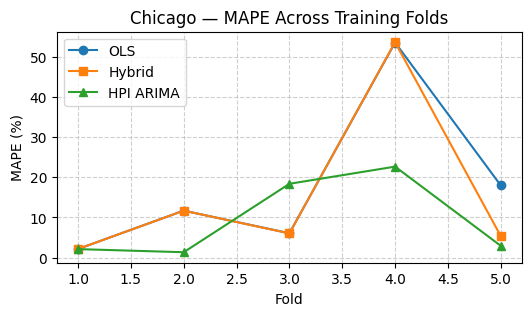

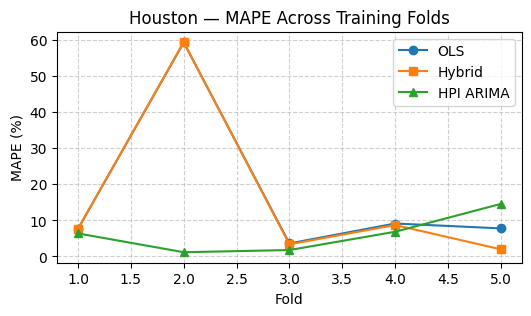

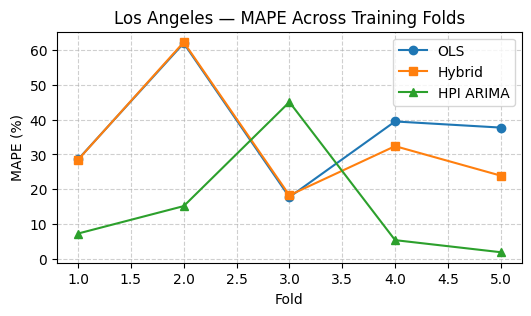

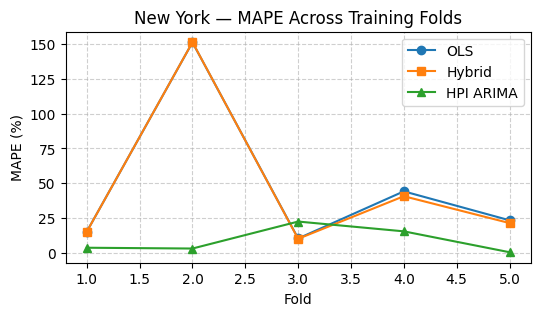

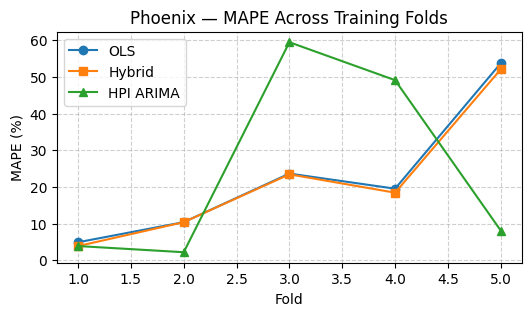

In [36]:
cv_summary = cv_df.groupby("City")[[
    "OLS_MAE", "OLS_RMSE", "OLS_MAPE",
    "Noise_MAE", "Noise_RMSE", "Noise_MAPE",
    "ARIMA_MAE", "ARIMA_RMSE", "ARIMA_MAPE"
]].mean().reset_index()

print(cv_summary.round(2))

cv_std = cv_df.groupby("City")[[
    "OLS_RMSE", "Noise_RMSE", "ARIMA_RMSE",
    "OLS_MAPE", "Noise_MAPE", "ARIMA_MAPE"
]].std().add_suffix("_std").reset_index()

cv_summary = cv_summary.merge(cv_std, on="City")
print(cv_summary.round(2))

# for city in cv_df["City"].unique():
#     subset = cv_df[cv_df["City"] == city]
#     plt.figure(figsize=(8,5))
#     plt.plot(subset["Fold"], subset["OLS_MAPE"], marker='o', label="OLS")
#     plt.plot(subset["Fold"], subset["Hybrid_MAPE"], marker='s', label="Hybrid")
#     plt.plot(subset["Fold"], subset["ARIMA_MAPE"], marker='^', label="ARIMA")
#     plt.title(f"{city} — MAPE Across Folds")
#     plt.xlabel("Fold")
#     plt.ylabel("MAPE (%)")
#     plt.grid(True, linestyle="--", alpha=0.6)
#     plt.legend()
#     plt.show()


for city in cv_df["City"].unique():
    subset = cv_df[(cv_df["City"] == city) & (cv_df["Type"] == "Training CV")]
    
    plt.figure(figsize=(6,3))
    plt.plot(subset["Fold"], subset["OLS_MAPE"], marker='o', label="OLS")
    plt.plot(subset["Fold"], subset["Noise_MAPE"], marker='s', label="Hybrid")
    
    if "ARIMA_MAPE" in subset.columns:
        plt.plot(subset["Fold"], subset["ARIMA_MAPE"], marker='^', label="HPI ARIMA")
    
    plt.title(f"{city} — MAPE Across Training Folds")
    plt.xlabel("Fold")
    plt.ylabel("MAPE (%)")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.show()




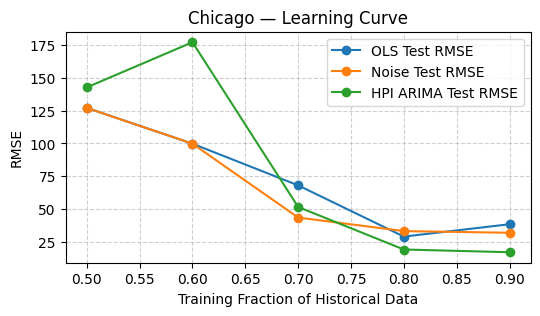

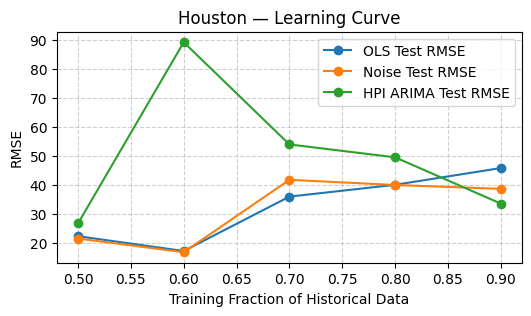

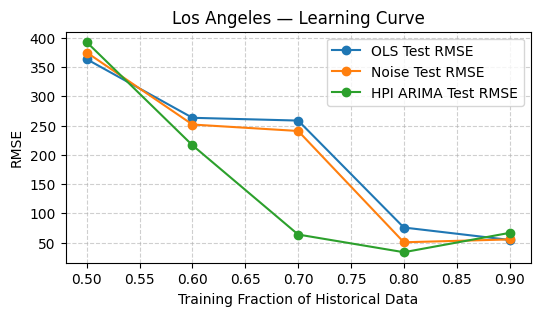

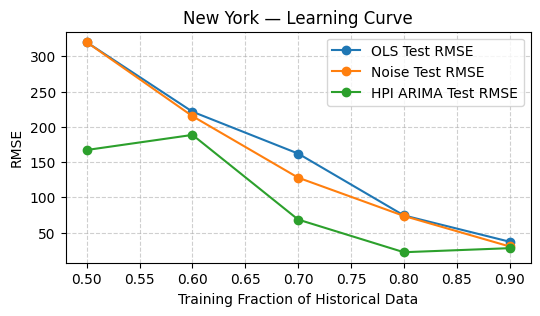

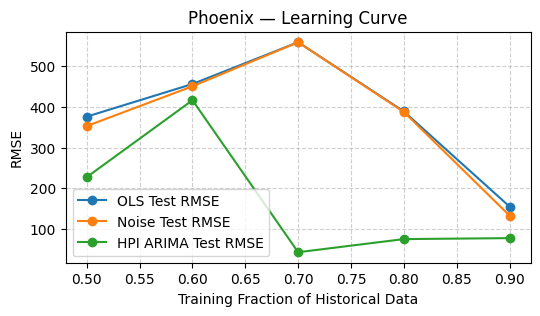

In [37]:


for city, city_df in final_df.groupby("City"):
    city_df = city_df.sort_values(["Year", "Quarter"]).reset_index(drop=True)
    y = city_df["index_nsa"]

    train_fracs = np.linspace(0.5, 0.9, 5)  
    ols_rmse_train, ols_rmse_test = [], []
    hybrid_rmse_test, arima_rmse_test = [], []

    for frac in train_fracs:
        split = int(len(city_df) * frac)
        train, test = city_df.iloc[:split], city_df.iloc[split:]
        X_train = sm.add_constant(train[features], has_constant="add")
        X_test = sm.add_constant(test[features], has_constant="add")
        y_train, y_test = train["index_nsa"], test["index_nsa"]

        ols_model = sm.OLS(y_train, X_train).fit()
        y_pred_train = ols_model.predict(X_train)
        y_pred_test = ols_model.predict(X_test)
        ols_rmse_train.append(np.sqrt(mean_squared_error(y_train, y_pred_train)))
        ols_rmse_test.append(np.sqrt(mean_squared_error(y_test, y_pred_test)))

        resid_train = y_train - y_pred_train
        arima_order_noise = best_orders.get(city, (1,1,1))
        arima_model_noise = ARIMA(resid_train, order=arima_order_noise).fit()
        hybrid_forecast = y_pred_test + arima_model_noise.forecast(steps=len(y_test))
        hybrid_rmse_test.append(np.sqrt(mean_squared_error(y_test, hybrid_forecast)))

        arima_order_hpi = best_orders_raw.get(city, (1,1,1))
        arima_model_hpi = ARIMA(y_train, order=arima_order_hpi).fit()
        arima_forecast = arima_model_hpi.forecast(steps=len(y_test))
        arima_rmse_test.append(np.sqrt(mean_squared_error(y_test, arima_forecast)))

    plt.figure(figsize=(6,3))
    plt.plot(train_fracs, ols_rmse_test, "o-", label="OLS Test RMSE")
    plt.plot(train_fracs, hybrid_rmse_test, "o-", label="Noise Test RMSE")
    plt.plot(train_fracs, arima_rmse_test, "o-", label="HPI ARIMA Test RMSE")
    plt.title(f"{city} — Learning Curve")
    plt.xlabel("Training Fraction of Historical Data")
    plt.ylabel("RMSE")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.show()

